In [222]:
import numpy as np
from numpy.linalg import eigh

from qiskit import QuantumCircuit,  QuantumRegister, ClassicalRegister, AncillaRegister, transpile, qasm2
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate, hamiltonian_variational_ansatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.synthesis import SuzukiTrotter
from qiskit.primitives import BackendEstimatorV2 as Estimator

import os

import quimb.tensor as qtn
import quimb as qu
from quimb.linalg.base_linalg import groundstate

import csv
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as tck

In this Jupyter notebook, I use the quimb tensor network package to approximate long TFIM chains, and then use the properties of MPS to evolve and measure the state in order to calculate the dichotomic time correlator $C_Q(t) = \langle \psi |\frac{1}{2} \{e^{i H t} Q e^{ - i H t}, Q \} | \psi \rangle $

In [191]:
def apply_gate(psi, measure_opp = 'Z', measure_site = 0):
    """Applies the measure_opp gate to the measure_site tensor of psi and returns a new psi"""
    
    L = len(psi.tensors)
    psi_Q = psi.copy()
    
    if len(measure_opp) == 1:
        Opp =qu.pauli(measure_opp)
        # Apply X gate to site n
        psi_Q = psi_Q.gate(Opp, measure_site, contract='swap+split')

    elif measure_opp == "X_even":

        for i in range(0, L, 2):
            Opp = qu.pauli('X')
            psi_Q = psi_Q.gate(Opp, i, contract='swap+split')

    return psi_Q


def DMRG_ising_GS(L, J = 1, h = 1):
    """Approxmate the ground state of the Ising model.
    Returns state, energy, and quimb.tensor.tn1d.tebd.LocalHam1D 
    class object suitable for TEBD evolution"""
    H_ising = qtn.SpinHam1D(S=1/2, cyclic=False)
    H_ising += -1.0 * J , 'Z', 'Z'
    H_ising += -1.0 * h , 'X'
    H_MPO = H_ising.build_mpo( L )
    H_ising_LocalHam = H_ising.build_local_ham( L )

    #run the DMRG procedure
    dmrg = qtn.DMRG2(H_MPO)
    dmrg.solve(max_sweeps=20, verbosity=0, cutoffs = 1e-09 )

    #call the ground state as a tensor network
    return dmrg.state, dmrg.energy, H_ising_LocalHam


def TFIM_DMRG_correlation(L, J = 1, h = 1, time_end = 2, time_step = 0.05, measure_site = 0, measure_opp = 'X', dt = 0.05, time_start = 0):
    """Calcuates C_Q(t) for ground state of Ising Hamiltonian 
    for t in time_range and outputs an array of C_Q(t). """

    if measure_site not in range(L):
        raise ValueError("measure_site not in the chain")
    elif  time_step * 10000 %1 != 0:
        raise ValueError("time_step * 1e4 should be a whole number for ease of calculating K")

    #call the ground state as a tensor network
    psi0, E0, H_ising_LocalHam = DMRG_ising_GS(L, J = J, h = h)

    #apply the measurement gate
    psi_Q = apply_gate(psi0, measure_opp = measure_opp, measure_site = measure_site)

    #The evolution is given by \exp(- i H t) | \psi >
    #time evolve for every time in time_range
    tebd = qtn.TEBD( psi_Q, H_ising_LocalHam, dt=dt  )

    correlation_C = []
    time_range = time_range = [round(t, 4) for t in np.arange(time_start, time_end, time_step)]
    for t in time_range:
        tebd.update_to(T = t, progbar = False)
        psi_t = tebd.pt
        psi_t = apply_gate(psi_t, measure_opp = measure_opp, measure_site = measure_site)
        Cor_C = psi0.H @ psi_t
        Cor_C *= np.exp(1j * E0 * t)
        Cor_C = np.real(Cor_C)
        correlation_C += [Cor_C]

    #eliminate machine-level precision error

    return time_range,  correlation_C

def TFIM_DMRG_LG_K(L, J = 1, h = 1, time_end = 2, time_step = 0.05, measure_site = 0, measure_opp = 'X', dt = 0.05):
    """Calculates the Legget-Garg correlation K = 2C(t) - C(2t)"""
    
    #Calculates C values from 0 to time_end
    times_1, leg_1 = TFIM_DMRG_correlation(L, J = J, h = h, time_end = time_end, time_step = time_step, measure_site = measure_site, measure_opp = measure_opp , dt = dt)
    #Calculates only the extra C values needed to calculate K
    times_2, leg_2 = TFIM_DMRG_correlation(L, J = J, h = h, time_end = 2 * time_end, time_start = time_end  ,time_step = 2* time_step, measure_site = measure_site, measure_opp = measure_opp , dt = dt)
    time_tot = times_1 + times_2
    cor_tot = leg_1 + leg_2

    K_lst = []
    # K = 2C(t) - C(2t)
    for i, t in enumerate(times_1):
        K_lst +=[leg_1[i] * 2 - cor_tot[time_tot.index(t* 2)]]
        
    return times_1, K_lst


We also want the quantum Fisher information

In [ ]:


J = 1
h = 1
L = 12
H_ising = qu.ham_ising(L , jz = -1.0 * J, bx = h)

ft.reduce(np.kron, State_array)

groundstate(H_ising)

492 ms ± 30.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
def Quantum_Fisher(state, Ham, Qop):
    '''calculates the Quantum Fisher information with respect to an operator Q given the state in the Hlbert space, the Hamiltonian, and the operator Q'''

    psi = state
    eig_values, eig_vectors = eigh(Ham)

    Qop =  Qop.to_matrix(sparse = False)  #turn into dense matrix

    QFI = 0
    for e in eig_vectors[1:]:
        psim = Qop @ e
        QFI += 4 * (np.abs(psim.dot(psi))) **2

    return QFI

ValueError: x and y must be the same size

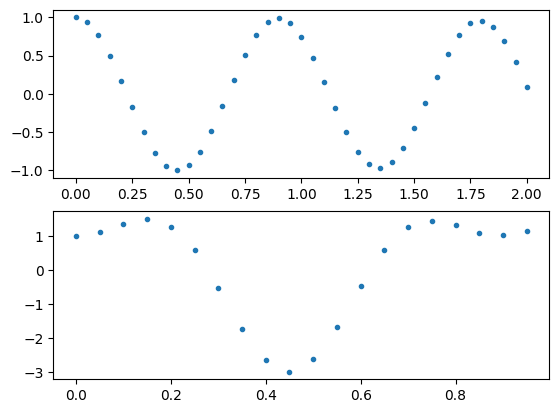

In [ ]:
chain_len = 8
J = 1
h = .1
op = "X_even"
step = .05
t_end = 2
psi = "GS"
layers = 20
PBC = False


fig, ax = plt.subplots(2)

#Generate tensor network data
times, dta_K = TFIM_DMRG_LG_K(chain_len, J = J, h= h, measure_site = chain_len//2, measure_opp = op, time_step = step, time_end = t_end)
times, dta_C = TFIM_DMRG_correlation(chain_len, J = J, h= h, measure_site = chain_len//2, measure_opp = op, time_step = step, time_end = t_end)

#generate quantum circuit data
layer = "layers" + str(layers)
csv_path = os.getcwd() + "/data/" + "L"+str(chain_len) + 'time'+ str(t_end) + 'd' + str( step)+ "J" + str(J) + "h" + str(h) +str(op) + "psi" + psi + layer +'PBC' + str(PBC) + '.csv'
   

with open(csv_path, newline='') as f:
    reader = csv.reader(f)
    [time_range, dta] = [[float(x) for x in row] for row in reader]
    
half_len = len(dta)//2
dta_K_Qis = [2 * dta[j] - dta[2 * j] for j in range(half_len) ]

ax[1].scatter(time_range[:half_len]  , dta_K_Qis ,  marker= ".", label = "VQE Circuit"   , zorder = 3)
ax[0].scatter(time_range  , dta ,  marker= ".", label = "VQE_Circuit" , zorder = 3)


ax[0].scatter( times  , dta_C ,  marker= ".", label = "MPS DMRG" , zorder = 3)
ax[1].scatter(times, dta_K ,  marker= ".", label = "MPS DMRG"   , zorder = 3)


#classical bound
#ax[1].axhline( y=1.5, color="0.9", linestyle = "--")
#ax[1].axhline( y=QFI_bound, color="0.9", linestyle = "--", label = "$1/8(F_Q) + \\langle (S^z_0 e^{i \\pi S^z_1}S^z_2)^2\\rangle$")


fig.suptitle("Q = " + op +" , $h = $" + str(h) + ", J = " + str(J) +" , N = " + str(chain_len))
ax[0].xaxis.set_major_locator(tck.MultipleLocator(base = .5))
ax[1].xaxis.set_major_locator(tck.MultipleLocator(base = .2))
plt.xlabel("time")
ax[0].set(ylabel = "C(t)")
ax[1].set(ylabel = "K(t) = 2C(t) - C(2t)")
#plt.ylim((0.9,1.6))
plt.title("")
plt.legend()

plt.show()

In [ ]:
lst =[.1, .2]


<method-wrapper '__mul__' of list object at 0x000001FD2CCEBBC0>